# Energy-Based Models

As we said in lecture, the most common example of the energy-based ML model is the *Boltzman machine*.

For the Boltzman machine, the loss function is related to the energy of the system or the information entropy.

This kind of ML architecture is conveniently mapped onto the 2-D Ising model because the energy function (Hamiltonian) is a fully connected energy function.
That is, each spin in the 2-D model is connected (theoretically) with all of the other spins.
In practice, of course, the interactions are limited to nearest neighbors.


# Ising Model Example

The 2-D Ising model is described by the Hamiltonian

$$H = -J \sum_{\langle i,j \rangle} s_i s_j$$

where the sum runs over nearest-neighbor pairs. (Here $i$ and $j$ don't refer to an coordinate pair but rather to an index in the list of spin locations.)

Because the system is governed by the Boltzmann distribution, spin configurations are drawn with probability $p(s) \propto e^{-H/k_BT}$.

If we are given only a set of spin configurations sampled at some temperature, can we learn an energy function $E(s; \theta)$ that reproduces the statistics of those configurations?
This is a prime example of generative modeling: it is just statistical mechanics with the couplings treated as free parameters to be inferred from data.

The key equation for today is the Boltzmann learning gradient  (Mehta Eq. 195):

$$\frac{\partial L}{\partial \theta_i} = \langle O_i(s) \rangle_{\text{data}} - \langle O_i(s) \rangle_{\text{model}}$$

where $O_i(s) = \partial E / \partial \theta_i$ has the energy dependence and $L$ is the log-likelihood. The first term is the positive phase (from data); the second is the negative phase (from "fantasy particles" sampled by MCMC).

## Metropolis MCMC to calculate energies

We use the Metropolis Markov Chain Monte Carlo for the nearest-neighbor Ising model on an $L \times L$ lattice.
The MCMC explores the different spin configurations in a probabilistic way.

If the spin values are set to $s_i \in \{0, 1\}$ (not physical, but more convenient for ML), then the energy in terms of $s_i$ is:

$$E(s) = -J \sum_{\langle i,j \rangle} (2s_i - 1)(2s_j - 1)$$

The energy change when spin $i$ is flipped is defined as $$\Delta E = 2(2s_i - 1) \sum_{j \notin i} J(2s_j - 1),$$ which can be computed locally.

In [3]:
import numpy as np
from copy import deepcopy

rng = np.random.default_rng(42)

def metropolis_sweep(s, T, L, J=1.0, rng=rng):
    # One sweep checks all L*L single-spin flip proposals
    s = s.copy()
    for _ in range(L * L):
        i, j = rng.integers(0, L, size=2)
        nb = [s[(i-1)%L, j], s[(i+1)%L, j], s[i, (j-1)%L], s[i, (j+1)%L]]
        dE = 2.0 * J * (2*s[i,j] - 1) * sum(2*n - 1 for n in nb)
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            s[i, j] = 1 - s[i, j]
    return s

def generate_ising_samples(T, L=10, n_samples=500, n_burn=2000,
                          n_thin=20, J=1.0, rng=rng):
    # We will generate half the samples starting
    # from either the all-up state or the all-down states
    half = n_samples // 2
    s_up = np.ones((L, L), dtype=int)
    s_dn = np.zeros((L, L), dtype=int)
    for _ in range(n_burn):
        s_up = metropolis_sweep(s_up, T, L, J, rng)
        s_dn = metropolis_sweep(s_dn, T, L, J, rng)
    samples = []
    for _ in range(half):
        for _ in range(n_thin):
            s_up = metropolis_sweep(s_up, T, L, J, rng)
            s_dn = metropolis_sweep(s_dn, T, L, J, rng)
        samples.append(s_up.flatten().copy())
        samples.append(s_dn.flatten().copy())
    return np.array(samples, dtype=np.float64)

### Visualization of configurations

In the following plots, dark squares have value 1 (spin +1) and light squares have value 0 (spin -1).

We plot configurations around the analytical solution of $T_c/J \approx 2.26$ (Onsager's exact result).

Generating samples...
  T/J = 1.75: done
  T/J = 2.25: done
  T/J = 2.75: done


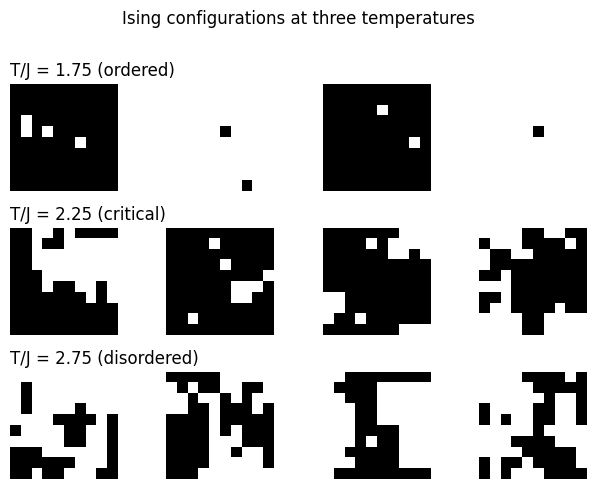

In [4]:
import matplotlib.pyplot as plt

L = 10
temperatures = [1.75, 2.25, 2.75]
T_labels = ['T/J = 1.75 (ordered)', 'T/J = 2.25 (critical)', 'T/J = 2.75 (disordered)']

print("Generating samples...")
samples = {}
for T in temperatures:
    samples[T] = generate_ising_samples(T, L=L, n_samples=500, n_burn=2000, n_thin=20)
    print(f"  T/J = {T}: done")

fig, axes = plt.subplots(3, 4)
for row, (T, label) in enumerate(zip(temperatures, T_labels)):
    for col in range(4):
        axes[row, col].imshow(samples[T][col].reshape(L, L),
                              cmap='binary', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_title(label, loc='left')
plt.suptitle('Ising configurations at three temperatures', y=1.01)
plt.tight_layout()
plt.show()

## Magnetization and susceptibility vs. temperature

Now we'll sweep across the range of temperatures and measure:
- Magnetization: $\langle |m| \rangle$ where $m = \frac{1}{N}\sum_i (2s_i-1)$, or switch back to physical spin values  
- Susceptibility: $\chi = N(\langle m^2 \rangle - \langle m \rangle^2)$

The susceptibility should peak near $T_c/J \approx 2.26$ (Onsager's exact result).

Sweeping temperatures...
  T/J = 1.00: <|m|> = 0.999, chi = 0.00
  T/J = 1.20: <|m|> = 0.998, chi = 0.01
  T/J = 1.40: <|m|> = 0.992, chi = 0.02
  T/J = 1.60: <|m|> = 0.982, chi = 0.05
  T/J = 1.80: <|m|> = 0.959, chi = 0.22
  T/J = 2.00: <|m|> = 0.914, chi = 0.65
  T/J = 2.20: <|m|> = 0.834, chi = 2.15
  T/J = 2.40: <|m|> = 0.616, chi = 6.37
  T/J = 2.60: <|m|> = 0.463, chi = 6.38
  T/J = 2.80: <|m|> = 0.365, chi = 4.53
  T/J = 3.00: <|m|> = 0.270, chi = 3.60
  T/J = 3.20: <|m|> = 0.250, chi = 2.76
  T/J = 3.40: <|m|> = 0.219, chi = 2.66
  T/J = 3.60: <|m|> = 0.186, chi = 1.91
  T/J = 3.80: <|m|> = 0.172, chi = 1.55
  T/J = 4.00: <|m|> = 0.166, chi = 1.32


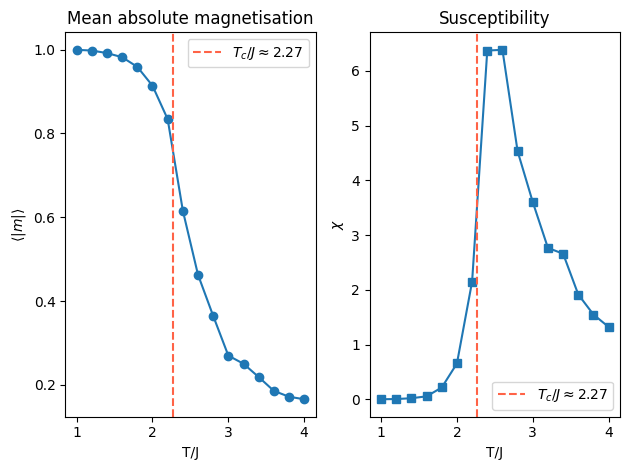

In [5]:
def magnetization_stats(samples):
    # Convert from {0,1} to {-1,+1} for calculation
    spins = 2.0 * samples - 1.0
    m = spins.mean(axis=1)
    abs_m = np.abs(m)
    N = samples.shape[1]
    mean_m  = abs_m.mean()
    chi     = N * (np.mean(m**2) - np.mean(np.abs(m))**2)
    return mean_m, chi

# A wider and finer sweep of temperatures centered on Tc
T_sweep = np.linspace(1.0, 4.0, 16)
mean_ms, chis = [], []

print("Sweeping temperatures...")
for T in T_sweep:
    s_T = generate_ising_samples(T, L=L, n_samples=300,
                                n_burn=2000, n_thin=20)
    mm, chi = magnetization_stats(s_T)
    mean_ms.append(mm)
    chis.append(chi)
    print(f"  T/J = {T:.2f}: <|m|> = {mm:.3f}, chi = {chi:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(T_sweep, mean_ms, 'o-')
ax1.axvline(2.269, ls='--', color='tomato', label='$T_c/J \\approx 2.27$')
ax1.set_xlabel('T/J'); ax1.set_ylabel(r'$\langle |m| \rangle$')
ax1.set_title('Mean absolute magnetisation'); ax1.legend()

ax2.plot(T_sweep, chis, 's-')
ax2.axvline(2.269, ls='--', color='tomato', label='$T_c/J \\approx 2.27$')
ax2.set_xlabel('T/J'); ax2.set_ylabel(r'$\chi$')
ax2.set_title('Susceptibility'); ax2.legend()

plt.tight_layout()
plt.show()

## MaxEnt Ising Model: Boltzmann Learning

We now fit a generalized Ising model with fully-connected (all-to-all) couplings $J_{ij}$ and local fields $a_i$ to the spin configurations at $T/J = 2.25$.
The energy function is:

$$E(s; J, a) = -\sum_i a_i s_i - \frac{1}{2}\sum_{i \neq j} J_{ij} s_i s_j$$

We will be adjusting the model parameters $\theta = \{J_{ij}, a_i\}$ to minimize the needed energy-based loss function. The operators conjugate to these are $O_{ij}(s) = s_i s_j$ and $O_i(s) = s_i$. The Boltzmann learning gradient becomes:
$$\frac{\partial L}{\partial J_{ij}} = \langle s_i s_j \rangle_{\text{data}} - \langle s_i s_j \rangle_{\text{model}}$$
$$\frac{\partial L}{\partial a_i} = \langle s_i \rangle_{\text{data}} - \langle s_i \rangle_{\text{model}}$$

The positive phase (from data moments) is computed directly from the training set. The negative phase (from model moments) requires MCMC sampling from the current model.

This code is kind of long, but that's because there are a lot of helper functions to calculate the statistical physics properties.

In [6]:
class MaxEntIsing:
    # Generalized Ising model with all-to-all couplings J_ij and local fields a_i,
    # from Mehta & Wang Sec. XV.D-E

    def __init__(self, N, l2=0.0, seed=None):
        self.N   = N
        self.l2  = l2
        self.rng = np.random.default_rng()
        self.J   = self.rng.normal(0, 0.01, size=(N, N))
        self.J   = (self.J + self.J.T) / 2  # keep symmetric
        np.fill_diagonal(self.J, 0)
        self.a   = np.zeros(N)

    def energy(self, s):
        # Energy of the current configuration s
        return -self.a @ s - 0.5 * s @ self.J @ s

    def _delta_E(self, s, k):
        # energy change when flipping spin k in configuration s
        return -(1 - 2 * s[k]) * (self.a[k] + self.J[k] @ s)

    def mcmc_sweep(self, s):
        # Single sweep means N single-spin flip opportunities
        s = s.copy()
        for k in self.rng.permutation(self.N):
            dE = self._delta_E(s, k)
            if dE <= 0 or self.rng.random() < np.exp(-dE):
                s[k] = 1 - s[k]
        return s

    def sample_fantasy_particles(self, v0_batch, n_steps=5):
        # Generate test ("fantasy") particles starting from v0_batch.
        fantasies = v0_batch.copy()
        for b in range(len(fantasies)):
            for _ in range(n_steps):
                fantasies[b] = self.mcmc_sweep(fantasies[b])
        return fantasies

    def fit(self, data, n_epochs=30, batch_size=50, lr=0.01,
            n_mcmc_steps=5, val_data=None, verbose=True):
        # Boltzmann learning via SGD.

        n = len(data)
        history = {'train_ll': [], 'val_ll': []}

        for epoch in range(n_epochs):

            # weight update loop
            idx = self.rng.permutation(n)
            ds  = data[idx]
            for start in range(0, n, batch_size):
                batch = ds[start:start + batch_size]

                # Positive phase: moments from data
                pos_s  = batch.mean(axis=0)
                pos_ss = (batch.T @ batch) / len(batch)
                np.fill_diagonal(pos_ss, 0)

                # Negative phase: moments from fantasy particles (MCMC)
                f = self.sample_fantasy_particles(batch.copy(), n_steps=n_mcmc_steps)
                neg_s  = f.mean(axis=0)
                neg_ss = (f.T @ f) / len(f)
                np.fill_diagonal(neg_ss, 0)

                # Gradient ascent (J kept symmetric)
                grad_J = (pos_ss - neg_ss) - self.l2 * self.J
                grad_a = pos_s - neg_s
                self.J += lr * (grad_J + grad_J.T) / 2
                self.a += lr * grad_a

            # loss monitor (runs after all weight updates this epoch)
            bf  = self.sample_fantasy_particles(self.rng.integers(0, 2, size=batch.shape).astype(float),
                                                n_steps=n_mcmc_steps)
            E_d = np.array([self.energy(s) for s in data[:200]])
            E_f = np.array([self.energy(s) for s in bf])
            ll  = -E_d.mean() + E_f.mean()
            history['train_ll'].append(ll)

            if val_data is not None:
                E_v = np.array([self.energy(s) for s in val_data[:200]])
                history['val_ll'].append(-E_v.mean() + E_f.mean())

            if verbose and (epoch % 5 == 0 or epoch == n_epochs - 1):
                msg = f'Epoch {epoch+1:3d}/{n_epochs}  train_LL = {ll:.4f}'
                if val_data is not None:
                    msg += f"  val_LL = {history['val_ll'][-1]:.4f}"
                print(msg)

        return history


    def model_moments(self, n_samples=1000, n_steps=30):
        # Estimate <s_i>_model and <s_i s_j>_model via MCMC
        s_init = self.rng.integers(0, 2, size=(n_samples, self.N)).astype(float)
        fantasies = self.sample_fantasy_particles(s_init, n_steps=n_steps)
        mean_s  = fantasies.mean(axis=0)
        mean_ss = (fantasies.T @ fantasies) / n_samples
        np.fill_diagonal(mean_ss, 0)
        return mean_s, mean_ss

### Training the model

Now that all that is done, we can move on to training the model on our configurations.

In [8]:
N = L * L  # = 100
T_train = 2.25

# Split into train / val
n_train = 400
train_data = samples[T_train][:n_train]
val_data   = samples[T_train][n_train:]

print(f"Training on {n_train} samples at T/J = {T_train}")
print(f"Validation: {len(val_data)} samples")

model_critical = MaxEntIsing(N=N, l2=1e-4, seed=1)

history = model_critical.fit(
    train_data,
    n_epochs=40,
    batch_size=50,
    lr=0.005,
    n_mcmc_steps=10,
    val_data=val_data,
    verbose=True
)

Training on 400 samples at T/J = 2.25
Validation: 100 samples
Epoch   1/40  train_LL = 7.4413  val_LL = 3.7057
Epoch   6/40  train_LL = 12.9026  val_LL = 4.6685
Epoch  11/40  train_LL = 12.1685  val_LL = 3.9014
Epoch  16/40  train_LL = 12.6044  val_LL = 4.1540
Epoch  21/40  train_LL = 12.0250  val_LL = 3.8060
Epoch  26/40  train_LL = 13.9900  val_LL = 6.1332
Epoch  31/40  train_LL = 12.4020  val_LL = 4.3028
Epoch  36/40  train_LL = 14.2326  val_LL = 6.3563
Epoch  40/40  train_LL = 15.3811  val_LL = 7.6151


Remember that these LL values are actually negative log likelihood values, so the absolute value is what's increasing with each epoch.

### Visualization of results

We could check a bunch of statistical quantities, but it might be most straightforward to check the coupling matrix directly.

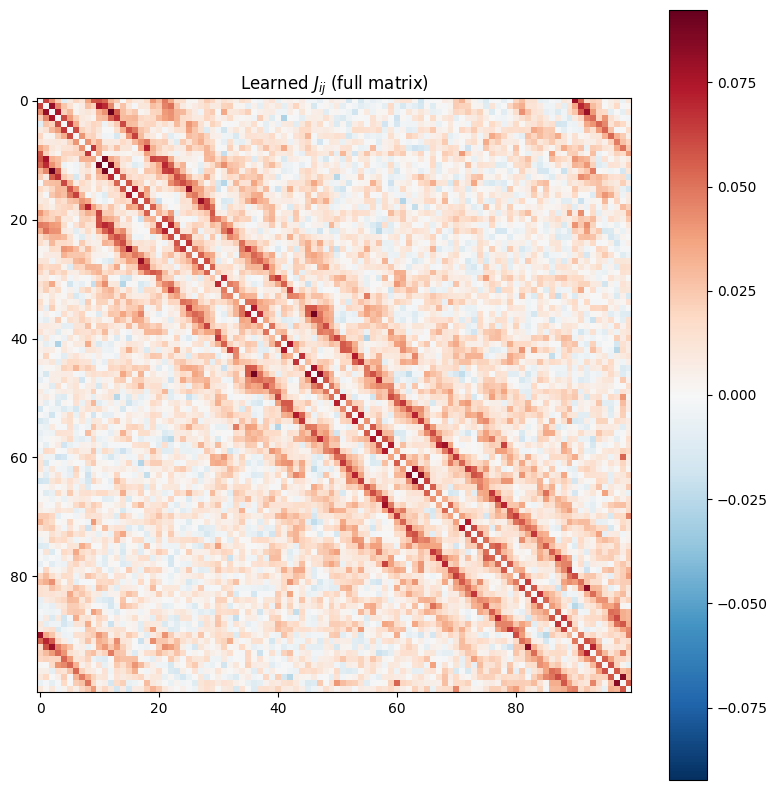

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
im0 = ax.imshow(model_critical.J, cmap='RdBu_r',
                     vmax=np.abs(model_critical.J).max(),
                     vmin=-np.abs(model_critical.J).max())
ax.set_title('Learned $J_{ij}$ (full matrix)')
fig.colorbar(im0, ax=ax)
plt.tight_layout()
plt.show()

### Conclusion

You can see that the 4 nearest neighbor couplings have been learned.

It turns out that the nearest-neighbor couplings should be $J/T = 1/2.25 \approx 0.44$. Our training did a pretty good job arriving at that number.